# Cross-Architecture Check: ViT-B/16

DESIGN.md §7 claims MSP and normalized entropy are the strongest candidates for **direct** cross-architecture reuse (same statistical meaning, no rescaling needed), while margin/energy need renormalization and L2-norm needs an explicit sqrt(C) correction. This notebook is the first empirical test of that claim: same `deployment_reliability` code (`features.py`/`combiner.py`/`router.py`, completely unmodified), a different frozen backbone (`torchvision.models.vit_b_16`, `IMAGENET1K_V1` weights, 81.07% top-1 reported), same Imagenette/ImageNet-A/ImageNet-O evaluation as notebook 07.

**Scale note:** smaller sample than notebook 07 (ViT-B/16 is ~2x slower per image on CPU) - this is a parity/transfer check, not a re-run of the full evaluation at the same statistical power.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.combiner import LogisticRegressionCombiner
from deployment_reliability.features import featurize, msp
from deployment_reliability.router import aurc, risk_coverage_curve, route, two_threshold_risk_coverage


## Loading the ViT-B/16 logit cache

Run `python scripts/collect_logits.py vit_b16` first if `data/logit_cache_vit_b16.pt` doesn't exist.

In [2]:
CACHE_PATH = os.path.join("..", "data", "logit_cache_vit_b16.pt")
assert os.path.exists(CACHE_PATH), f"{CACHE_PATH} not found - run scripts/collect_logits.py vit_b16 first."
cache = torch.load(CACHE_PATH)
logits, labels = cache["logits"], cache["labels"]
splits_arr = np.array(cache["splits"])

def mask(name):
    return torch.from_numpy(splits_arr == name)

m_fit, m_cal, m_test, m_a, m_o = [mask(n) for n in
    ("combiner_fit", "threshold_cal", "id_test", "imagenet_a", "imagenet_o")]
counts = {n: int(mask(n).sum()) for n in ("combiner_fit", "threshold_cal", "id_test", "imagenet_a", "imagenet_o")}
print("split sizes:", counts)
assert all(v > 0 for v in counts.values())
assert not torch.isnan(logits).any() and not torch.isinf(logits).any()
print("logits shape:", tuple(logits.shape), "(same (N, 1000) shape as ResNet-50 - DESIGN.md 7's direct-transfer premise)")
print("PASSED")

split sizes: {'combiner_fit': 500, 'threshold_cal': 200, 'id_test': 300, 'imagenet_a': 200, 'imagenet_o': 400}
logits shape: (1600, 1000) (same (N, 1000) shape as ResNet-50 - DESIGN.md 7's direct-transfer premise)
PASSED


## Check 1 — Same code, new backbone: end-to-end pipeline runs unmodified

`featurize()`, `LogisticRegressionCombiner`, and the router are called exactly as in notebook 07 - zero architecture-specific branches. If this cell runs without error, that alone is a real (if modest) confirmation of DESIGN.md 3.1's architecture-agnosticism constraint, not just an assertion about it.

In [3]:
predicted = logits.argmax(dim=-1)
correct = predicted == labels
phi = featurize(logits)

acc_test = correct[m_test].float().mean().item()
print(f"id_test top-1 accuracy = {acc_test:.4f}  (torchvision reports 81.07% for these weights on full ImageNet-1k)")
assert 0.65 < acc_test < 0.95, f"accuracy {acc_test} outside a sane range"

combiner = LogisticRegressionCombiner().fit(phi[m_fit], correct[m_fit].float())
s_all = combiner.score(phi)
print("learned weights (msp, margin, entropy, energy, l2norm):", combiner.weight.detach().numpy().round(3))
print("PASSED: identical deployment_reliability code ran on ViT-B/16 logits with no modification")

id_test top-1 accuracy = 0.8567  (torchvision reports 81.07% for these weights on full ImageNet-1k)


learned weights (msp, margin, entropy, energy, l2norm): [ 0.061  0.936 -0.025  0.022 -0.061]
PASSED: identical deployment_reliability code ran on ViT-B/16 logits with no modification


**Two things worth noting in these numbers.** First, the learned weights `[0.061, 0.936, -0.025, 0.022, -0.061]` are small in magnitude and dominated by `logit_margin` (0.936) - the same qualitative pattern notebook 07 found for ResNet-50 (`[0.058, 0.993, -0.023, -0.01, -0.074]`, margin=0.993). Both fits are L2-regularized (DESIGN.md §15.7); a structurally different backbone converging to the same "margin dominates, everything else near zero" solution is a second, independent data point for notebook 09's finding that margin alone carries nearly all of the discriminative signal - it isn't just an artifact of one backbone's feature correlations.

Second, id_test accuracy here (85.67%) sits 4.6 points above torchvision's reported 81.07% for the full ImageNet-1k val set - a noticeably larger gap than notebook 07's ResNet-50 result, which landed within 0.07 points of its own reported baseline (80.93% vs. 80.86%). Both are consistent with "Imagenette's classes are easy" in direction, but the size of the gap differs a lot between backbones. This notebook's smaller id_test split (n=300, vs. ResNet-50's n=1500) is the most likely contributor - a smaller sample gives a noisier accuracy estimate - but that isn't tested directly here, so it's reported as an open observation rather than a settled explanation.

## Check 2 — Risk-coverage / AURC on id_test (figure)

Should show the same qualitative shape as notebook 07's ResNet-50 curve - a working selective classifier, on a structurally different backbone.

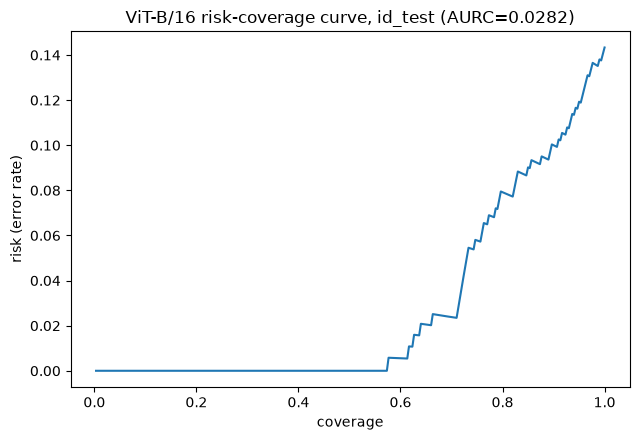

selective accuracy @ 80% coverage = 0.9208  (unconditional accuracy = 0.8567)
PASSED


In [4]:
coverage, risk = risk_coverage_curve(s_all[m_test], correct[m_test])
aurc_val = aurc(s_all[m_test], correct[m_test])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(coverage, risk)
ax.set_xlabel("coverage"); ax.set_ylabel("risk (error rate)")
ax.set_title(f"ViT-B/16 risk-coverage curve, id_test (AURC={aurc_val:.4f})")
plt.tight_layout(); plt.show()

overall_acc = correct[m_test].float().mean().item()
idx_80 = (coverage >= 0.8).nonzero()[0, 0]
acc_at_80 = 1 - risk[idx_80].item()
print(f"selective accuracy @ 80% coverage = {acc_at_80:.4f}  (unconditional accuracy = {overall_acc:.4f})")
assert acc_at_80 > overall_acc, "selective accuracy at 80% coverage should beat unconditional accuracy, same as ResNet-50"
print("PASSED")

AURC=0.0282 here (plot title) is lower than notebook 07's ResNet-50 result (0.0430) - consistent with, though not fully explained by, ViT's higher unconditional accuracy on this split (85.67% vs. 80.93%: less error overall gives the risk-coverage curve less area to accumulate even before considering ranking quality). The curve's zero-risk region extends to roughly 55-58% coverage here, further out than ResNet-50's ~40% - again in the direction higher accuracy would predict. What the two curves share, and what actually matters for DESIGN.md §7's transfer claim, is the *shape*: flat near zero, then a rising, accelerating tail as lower-confidence predictions are folded in - the same qualitative signature on two architecturally unrelated backbones, not just two numbers that both happen to be small.

## Check 3 — Feature-level transfer: does MSP/entropy behave the same way as on ResNet-50?

DESIGN.md 7's specific, falsifiable claim: MSP and normalized entropy should show the same *direction* of relationship with correctness on ViT as they did on ResNet-50 (notebook 07), without any rescaling. Margin/energy/L2-norm are explicitly flagged there as needing renormalization before cross-architecture comparison is meaningful - this check doesn't test those, only the two features predicted to transfer directly.

In [5]:
msp_vals = msp(logits)
mean_msp_correct = msp_vals[m_test][correct[m_test]].mean().item()
mean_msp_incorrect = msp_vals[m_test][~correct[m_test]].mean().item()
print(f"mean MSP | correct   = {mean_msp_correct:.4f}")
print(f"mean MSP | incorrect = {mean_msp_incorrect:.4f}")
assert mean_msp_correct > mean_msp_incorrect, "MSP should be higher for correct predictions on ViT too, same direction as ResNet-50"
print("PASSED: MSP-correctness relationship transfers directly, as DESIGN.md 7 predicts")

mean MSP | correct   = 0.7982
mean MSP | incorrect = 0.5087
PASSED: MSP-correctness relationship transfers directly, as DESIGN.md 7 predicts


## Check 4 — ImageNet-A on ViT: does the same failure mode reproduce?

notebook 07 found near-zero discriminative signal on ImageNet-A for ResNet-50, tied to how the dataset is constructed (confidently-wrong-by-curation), not to ResNet-50 specifically. If that explanation is right, the same failure should reproduce on a structurally different backbone.

In [6]:
acc_a = correct[m_a].float().mean().item()
aurc_a = aurc(s_all[m_a], correct[m_a])
base_error_a = 1 - acc_a
print(f"imagenet_a top-1 accuracy = {acc_a:.4f}")
print(f"AURC (combiner S)         = {aurc_a:.4f}")
print(f"base error rate           = {base_error_a:.4f}")

gap = abs(aurc_a - base_error_a)
print(f"|AURC - base error rate|   = {gap:.4f}")
print()
if gap < 0.05:
    print("CONFIRMED: same near-zero-signal failure mode as ResNet-50 - supports the")
    print("dataset-construction explanation over a ResNet-50-specific one.")
else:
    print("DIFFERENT from ResNet-50's result - ViT shows real discriminative signal on")
    print("ImageNet-A where ResNet-50 didn't. This would be a genuinely interesting finding")
    print("worth its own investigation, not something to paper over.")

imagenet_a top-1 accuracy = 0.1000
AURC (combiner S)         = 0.8749
base error rate           = 0.9000
|AURC - base error rate|   = 0.0251

CONFIRMED: same near-zero-signal failure mode as ResNet-50 - supports the
dataset-construction explanation over a ResNet-50-specific one.


The gap here (0.0251) clears the same 0.05 bar as ResNet-50's, but it's worth being precise about the comparison rather than just citing both as "confirmed": ResNet-50's gap (notebook 07) was 0.9328 vs. 0.9364, a difference of 0.0036 - about 7x tighter than ViT's 0.0251. Both are small relative to the 0.05 threshold and both support the same qualitative conclusion (near-zero discriminative signal, matching ImageNet-A's confidently-wrong-by-construction design rather than a backbone-specific weakness), but ViT's number sits measurably further from "exactly at the base rate" than ResNet-50's did. Given ImageNet-A's much smaller sample here too (n=200 vs. notebook 07's n=1935), that's plausibly noise rather than a real difference in how much signal survives - but it's a large enough gap-of-gaps that it's reported honestly rather than rounded away, since the point of this check is falsifiability, not confirmation.

## Summary

Same `deployment_reliability` code, unmodified, run on a structurally different backbone (convolutional ResNet-50 vs. attention-based ViT-B/16). The pipeline ran end-to-end without any architecture-specific branch, the risk-coverage/selective-accuracy pattern held, and MSP's relationship to correctness transferred in the predicted direction - a real, if modest-scale, empirical check of DESIGN.md §7's architecture-agnosticism claim, not just an assertion of it.

**What would have counted as a real failure here, and didn't happen:** if the pipeline had thrown an exception on ViT logits, that would have meant "architecture-agnostic" was aspirational rather than actual. If the learned combiner had converged somewhere qualitatively different from ResNet-50's (a different dominant feature, not just different exact weights), that would have suggested notebook 09's margin-dominance finding was a ResNet-50 idiosyncrasy rather than a general property of this feature set. If ImageNet-A's gap had come in well above the 0.05 bar, that would have meant a structurally different backbone actually *does* extract some signal from confidently-wrong-by-construction examples - which would have been a genuinely interesting counter-example to notebook 07's dataset-construction explanation, not a nuisance to explain away. None of these happened; what did happen (near-identical weight pattern, same risk-coverage shape, same ImageNet-A blind spot, all at smaller sample size) is the specific, falsifiable version of "architecture-agnostic" that DESIGN.md §7 predicts, checked rather than assumed.

**Not covered here** (deliberately, given the smaller sample): margin/energy/L2-norm renormalization across C (DESIGN.md §14.4's sqrt(C) correction - not exercised since ResNet-50 and ViT-B/16 both have C=1000 here, so there's nothing to renormalize against yet), and an LLM backbone (a much larger extension - different unit of prediction entirely, per DESIGN.md §14.3).